In [163]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import stats

from sklearn import set_config
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error

In [51]:
import warnings
warnings.filterwarnings("ignore")

In [52]:
df = pd.read_csv('medical_insurance.csv')

In [53]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [54]:
df.shape

(2772, 7)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [56]:
df.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

In [57]:
df.describe(include='all')

,age,sex,bmi,children,smoker,region,charges
count,2772.000000,2772,2772.000000,2772.000000,2772,2772,2772.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,1406,NaN,NaN,2208,766,NaN
mean,39.109668,NaN,30.701349,1.101732,NaN,NaN,13261.369959
std,14.081459,NaN,6.129449,1.214806,NaN,NaN,12151.768945
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,26.000000,NaN,26.220000,0.000000,NaN,NaN,4687.797000
50%,39.000000,NaN,30.447500,1.000000,NaN,NaN,9333.014350
75%,51.000000,NaN,34.770000,2.000000,NaN,NaN,16577.779500


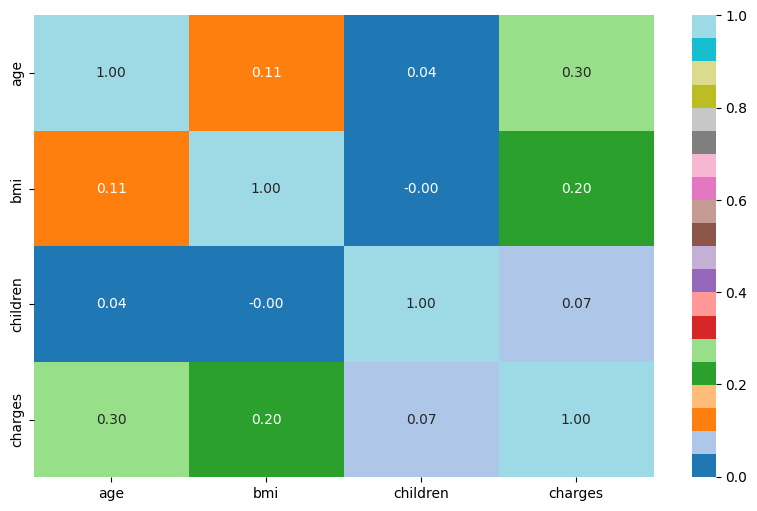

In [58]:
plt.figure(figsize=(10,6))
sns.heatmap(data=df.corr(numeric_only=True),cmap='tab20',fmt='.2f',annot=True)
plt.show()

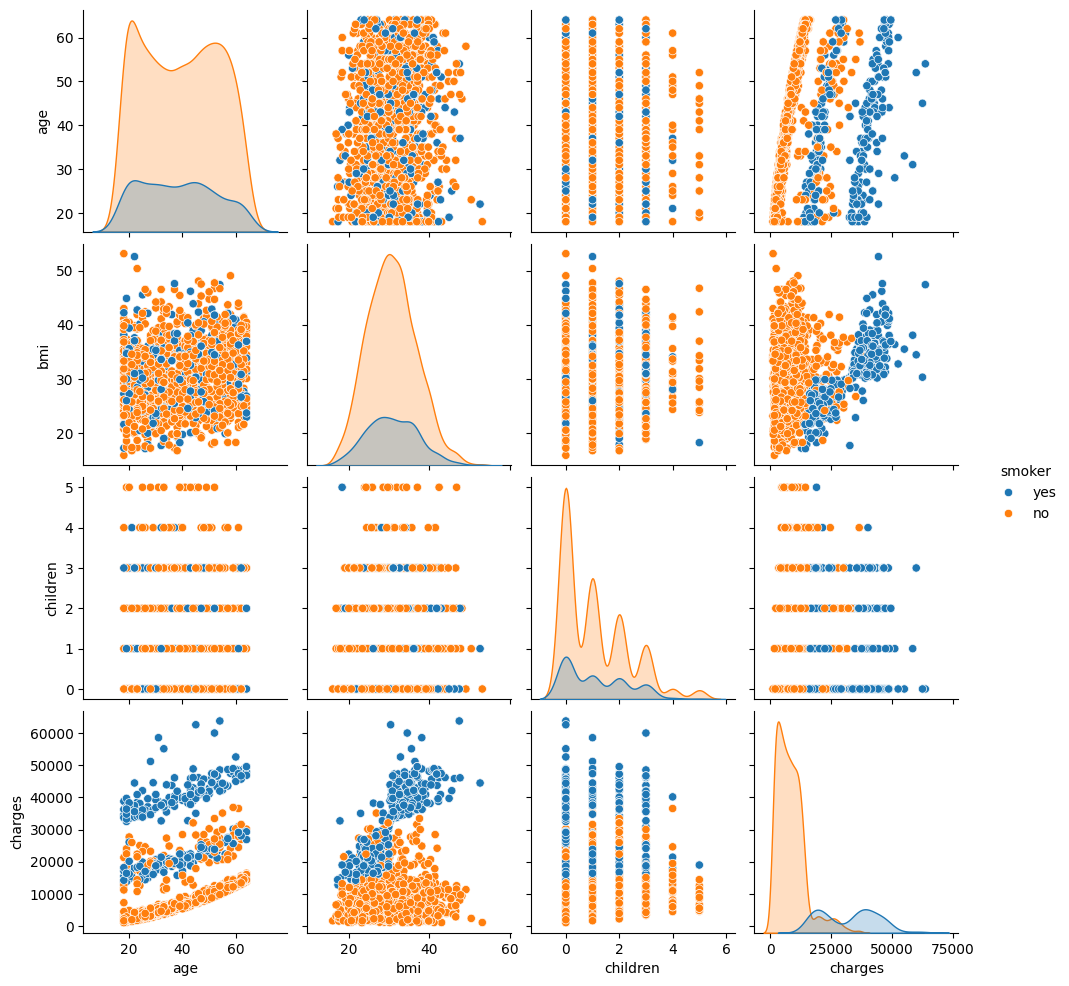

In [59]:
sns.pairplot(data=df,hue='smoker')
plt.show()

In [60]:
# We can either choose between columns to drop , but we have few columns to begin with we wont

In [61]:
# NUMERIC columns analysis 

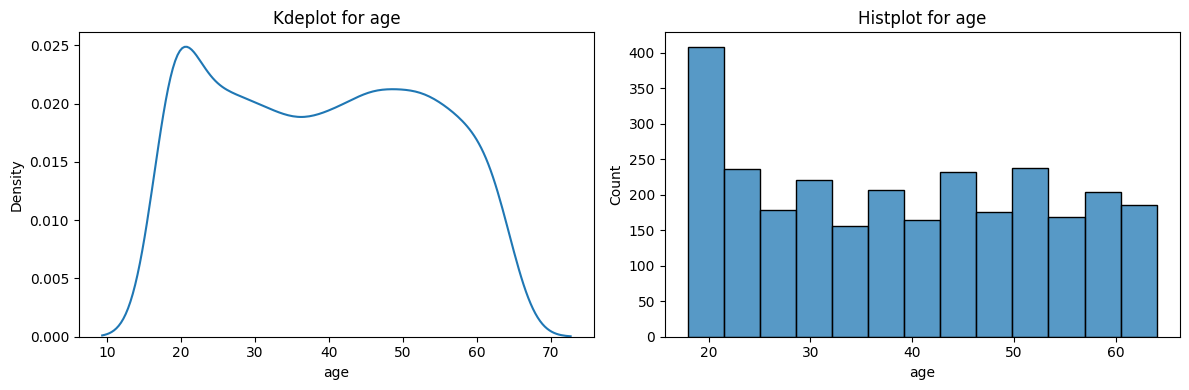

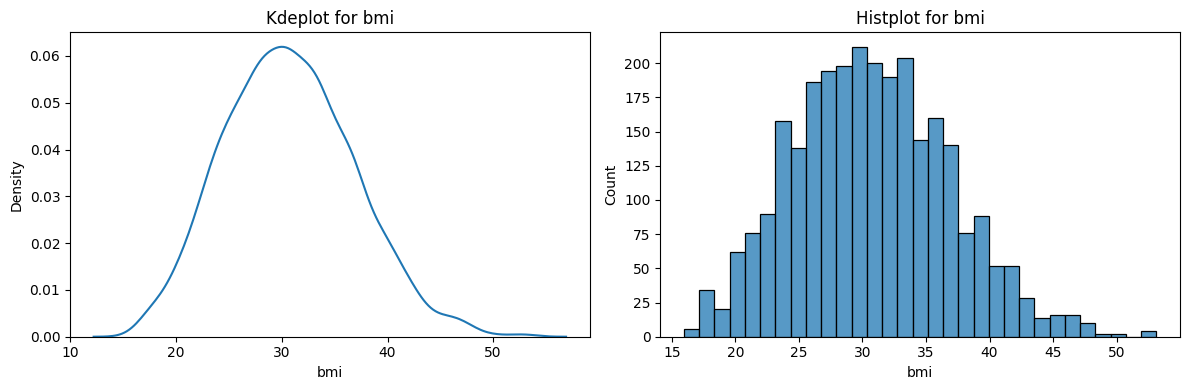

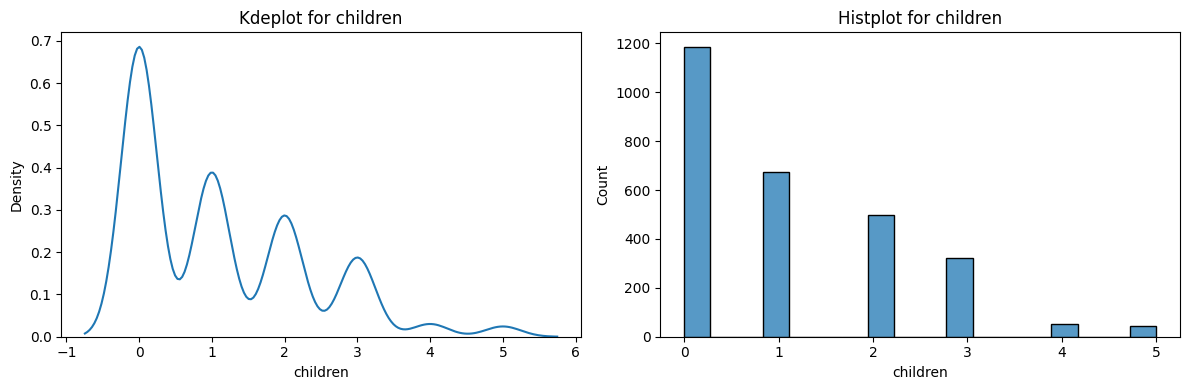

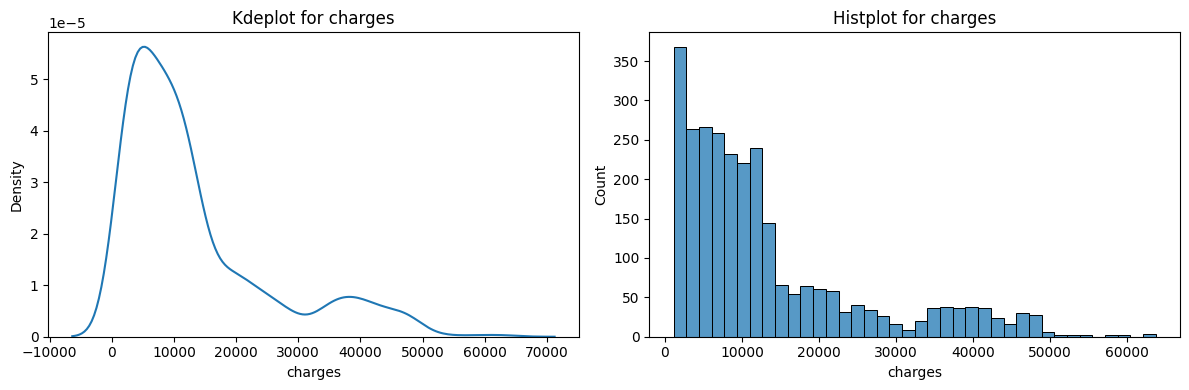

In [62]:
for x in df.select_dtypes('number').columns:

    plt.figure(figsize=(12,4))
    
    plt.subplot(121)
    sns.kdeplot(data=df[x])
    plt.title(f'Kdeplot for {x}')


    plt.subplot(122)
    sns.histplot(data=df[x])
    plt.title(f'Histplot for {x}')

    plt.tight_layout()
    plt.show()


In [63]:
# Leaving bmi other columns are skewed , we need to apply some transformations to fix this 

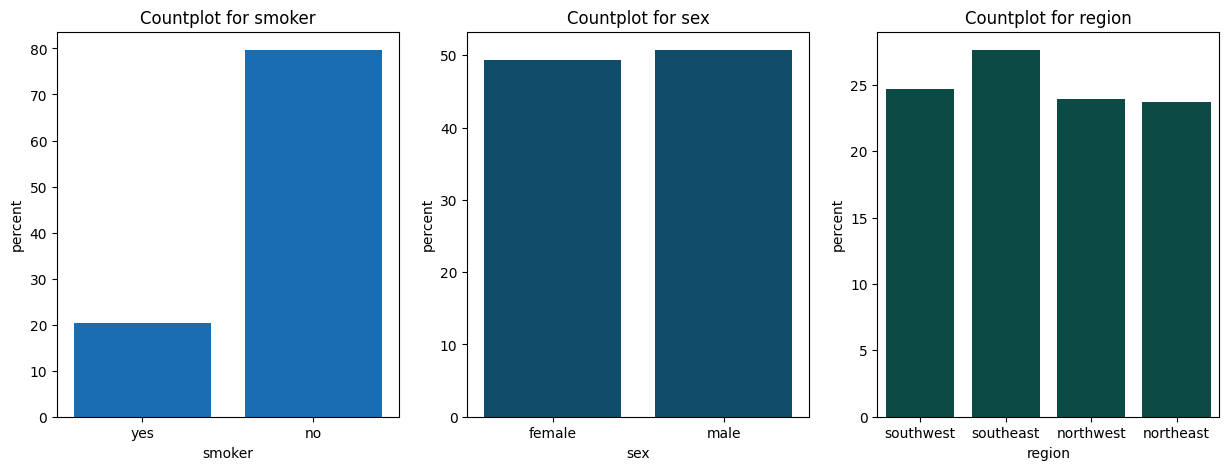

In [64]:
# Categorical columns analysis 

plt.figure(figsize=(15,5))

plt.subplot(131)
sns.countplot(x=df['smoker'],stat='percent',color="#0070CC")
plt.title(f'Countplot for smoker')

plt.subplot(132)
sns.countplot(x=df['sex'],stat='percent',color="#005379")
plt.title(f'Countplot for sex')

plt.subplot(133)
sns.countplot(x=df['region'],stat='percent',color="#00554E")
plt.title(f'Countplot for region')

plt.show()

In [65]:
# Smoker class is imbalanced

In [66]:
# age column seems to show the highest corr with the charges 

In [67]:
X , y = df.drop(columns=['charges']),df['charges']

In [68]:
X_train , X_test , y_train , y_test  = train_test_split(X,y,test_size=0.3,random_state=42)

In [69]:
c1 = ColumnTransformer(
    transformers=[
                            ('ord',OrdinalEncoder(),['smoker','sex']),
                            ('onc',OneHotEncoder(sparse_output=False,handle_unknown='ignore'),['region'])
    ],
    remainder='passthrough'
)

In [70]:
lr_pipe = Pipeline([
                        ('col1',c1),
                        ('scale',StandardScaler()),
                        ('lr',LinearRegression())
])

In [71]:
lr_pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('col1', ...), ('scale', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ord', ...), ('onc', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [72]:
y_pred = lr_pipe.predict(X_test)

In [73]:
r2_score(y_test,y_pred)

0.7443308125692926

In [74]:
mean_absolute_error(y_test,y_pred)

4224.767553044499

In [75]:
root_mean_squared_error(y_test,y_pred)

6324.887030009213

In [76]:
residuals = y_test - y_pred

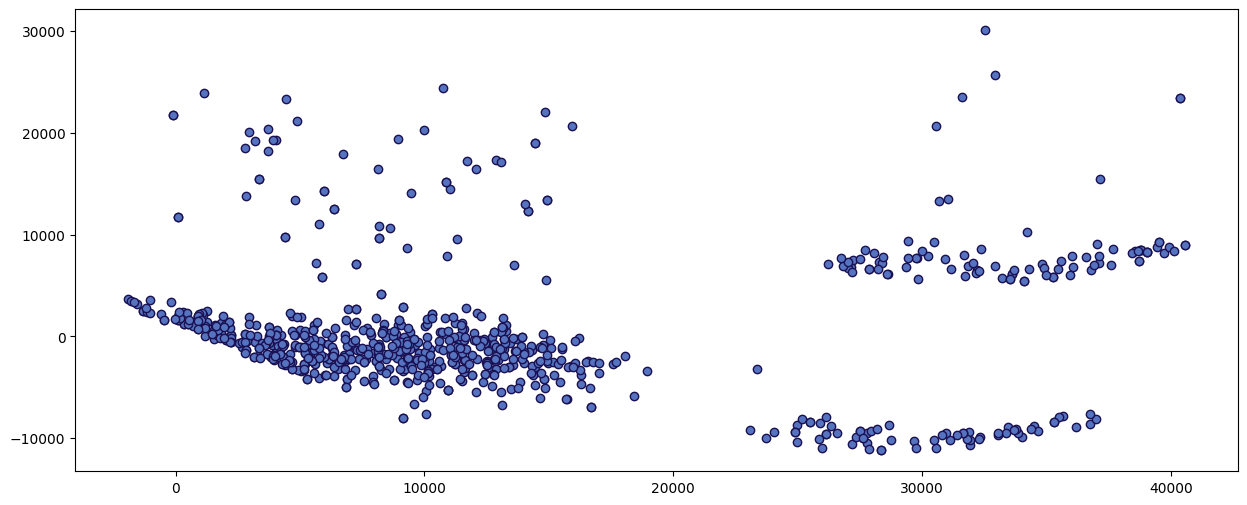

In [77]:
plt.figure(figsize=(15,6))
plt.scatter(y_pred,residuals,color="#5573BF",edgecolors="#1A1052")
plt.show() # Not random

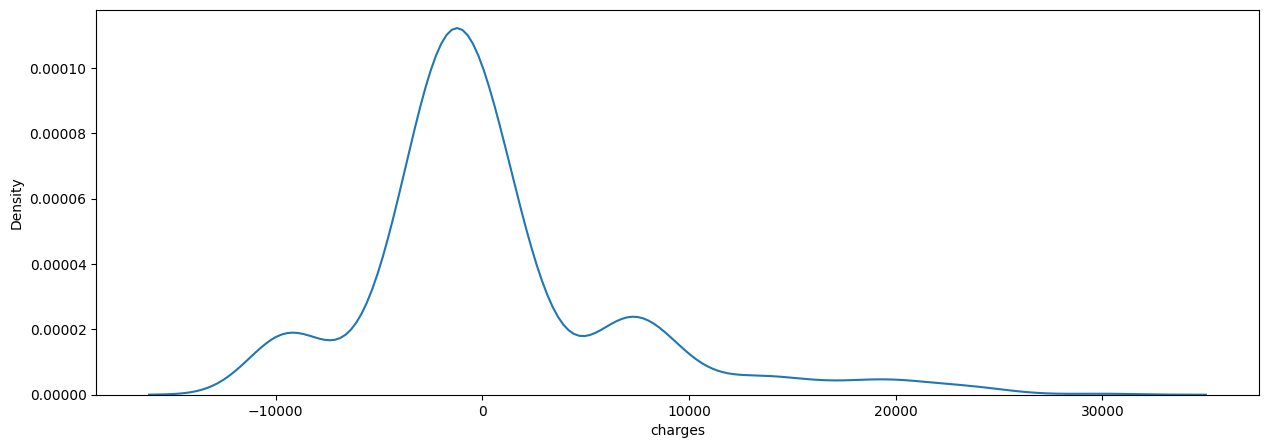

In [78]:
plt.figure(figsize=(15,5))
sns.kdeplot(residuals)
plt.show() # Not normal

In [79]:
# plt.figure(figsize=(15,6))
# stats.probplot(residuals,dist='norm',plot=plt)
# plt.show()
# # Waving so residuals have a waving tool , not good

In [80]:
# As seen above many conditions failed for linear regression so we need a fix

In [81]:
# Now we will go up and try to fix again some issues and come back again

In [82]:
# Now I will apply some transormations on each of the columns , to check and check its performance after this transformation 

In [83]:
# Things to check : 
'''
Does the imbalancedness of smoker column affects the dataset,
Should we remove less contributing columns
'''

'\nDoes the imbalancedness of smoker column affects the dataset,\nShould we remove less contributing columns\n'

In [84]:
from sklearn.preprocessing import FunctionTransformer,PowerTransformer

In [ ]:
# For avoiding typing multiple lines again I will create this function

# 1. CRITICAL: Global config to keep column names throughout the pipeline
set_config(transform_output="pandas")

def column_transformer_pipeline(
                                X_train,
                                y_train,
                                ct_2_transformers
                                ):
    
    # Column Transformer 1
    ct_1 = ColumnTransformer(
    transformers=[
                            ('ord',OrdinalEncoder(),['smoker','sex']),
                            ('onc',OneHotEncoder(sparse_output=False,handle_unknown='ignore'),['region'])
    ],
    remainder='passthrough'
    )



    # Main pipe

    lr_pipe = Pipeline([
                        ('col1',ct_1) , # Column Transformer 1  
                        ('col2',ColumnTransformer(transformers=ct_2_transformers,remainder='passthrough')) ,  # Column Transformer 2 
                        ('scale',StandardScaler()),
                        ('lr',LinearRegression())
    ])
    
    # Fitting , prediction and residuals

    lr_pipe.fit(X_train,y_train)
    y_pred = lr_pipe.predict(X_test)
    residuals = y_test - y_pred

    print()

    # Evaluation
    print(f'The r2 score for this pipeline : {r2_score(y_test,y_pred)}')
    print(f'The mae for this pipeline : {mean_absolute_error(y_test,y_pred)}')
    print(f'The rmse for this pipeline : {root_mean_squared_error(y_test,y_pred)}')

    print()

    # # Linear Assumpitons and Residual Analysis

    # plt.figure(figsize=(15,6))
    # plt.scatter(y_pred,residuals,color="#5573BF",edgecolors="#1A1052")
    # plt.show() 

    # plt.figure(figsize=(15,5))
    # sns.kdeplot(residuals)
    # plt.show() 


In [165]:
# We pass the transformer and then we check for the results for any improvements

column_transformer_pipeline(
        X_train ,
        y_train,
        # FunctionTransformer(func = np.log1p ).fit_transform(y_train), # Using Log Transformation to fix the skewness of the output column
    [
    # Column Transformer 2 list 
    ('log',FunctionTransformer(func=lambda x : x**(3)),['remainder__bmi','remainder__age']),
    ('pow',PowerTransformer(method='yeo-johnson'),['remainder__children'])

    ]
)

# Some Improvement


The r2 score for this pipeline : 0.385080581731318
The mae for this pipeline : 4892.193954073292
The rmse for this pipeline : 9808.953622180798



In [167]:
column_transformer_pipeline(
    X_train,
    y_train,
    [
        # Keep it simple: log for age/bmi, power for children
        ('log', FunctionTransformer(func=np.log1p), ['remainder__age', 'remainder__bmi']),
        ('pow', PowerTransformer(method='yeo-johnson'), ['remainder__children'])
    ]
)



The r2 score for this pipeline : 0.5870586105821405
The mae for this pipeline : 4246.749018027942
The rmse for this pipeline : 8038.181064189169

